# **Logistics Delivery Performance Analysis**

**Objective:**
 Analyze logsitics delivery performance data to identify key affecting delivery speed, efficiency, and agent ratings.

 This project explores delivery times and predictive modeling to improve logistics decision-making.

**Questions**
 - What factors contribute the most to delivery delays (distance, areas, weather)?
- Which areas or categories perform best or worst?
- How do delivery delays impact Agent Ratings?
- Can we predict whether a delivery will be slow?


# **DATA COLLECTION**

Import libraries

In [284]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

Load Data

In [285]:
df = pd.read_csv('/amazon_delivery.csv')

#view the first rows of our dataframe
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [322]:
#view our data types and column names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Order_ID            43739 non-null  object  
 1   Agent_Age           43739 non-null  int64   
 2   Agent_Rating        43739 non-null  float64 
 3   Store_Latitude      43739 non-null  float64 
 4   Store_Longitude     43739 non-null  float64 
 5   Drop_Latitude       43739 non-null  float64 
 6   Drop_Longitude      43739 non-null  float64 
 7   Order_Date          43739 non-null  object  
 8   Order_Time          43739 non-null  object  
 9   Pickup_Time         43739 non-null  object  
 10  Weather             43739 non-null  object  
 11  Traffic             43739 non-null  object  
 12  Vehicle             43739 non-null  object  
 13  Area                43739 non-null  object  
 14  Delivery_Time       43739 non-null  int64   
 15  Category            43739 non-null  

In [287]:
#View basic statistics from the dataset
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [288]:
#How many rows and columns does the dataset have?
df.shape

(43739, 16)

# **DATA CLEANING AND WRANGLING**

In [289]:
#check for duplicate values
print(df.duplicated().sum())

0


In [290]:
#Check Missing Values
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [291]:
#view the median value in AgentRating
AGR_median = df['Agent_Rating'].median()
#view the most frequent value in Weather
Weather_most_frequent_value = df['Weather'].mode()[0]

print ("Most frequent value in AgentRating:", AGR_median)
print ("Most frequent value in Weather:", Weather_most_frequent_value)

Most frequent value in AgentRating: 4.7
Most frequent value in Weather: Fog


In [292]:
#Imput these columns with the most frequent values and its median
df['Agent_Rating'] = df['Agent_Rating'].fillna(AGR_median)
df['Weather'] =df['Weather'].fillna(Weather_most_frequent_value)

#confirm that the nulls were replaced
df.isnull().sum()


,0
Order_ID,0
Agent_Age,0
Agent_Rating,0
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


Normalization

In [293]:
#create a new column for normalized agent_ratings with min_max
min_val = df['Agent_Rating'].min()
max_val = df['Agent_Rating'].max()

df['AgentRating_MinMax'] = (df['Agent_Rating'] - min_val) / (max_val - min_val)

In [294]:
#verify the scaling worked
print(df['AgentRating_MinMax'].describe())

count    43739.000000
mean         0.726772
std          0.066904
min          0.000000
25%          0.700000
50%          0.740000
75%          0.780000
max          1.000000
Name: AgentRating_MinMax, dtype: float64


Feature Engineering

In [295]:
#Id like for us to have some sort of distance measure, but it seems we do not have that available, so we will use our longitutde and latitudes

#Using the Haversine formula we will create a distance measure, which is a formula used a lot in logistics

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 #earth's radius  in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2))* sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c



In [296]:
#create distance field
df['Distance_in_km'] = df.apply(lambda row: haversine(row['Store_Latitude'], row['Store_Longitude'], row['Drop_Latitude'], row['Drop_Longitude']),axis = 1)
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,AgentRating_MinMax,Distance_in_km
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,0.78,3.025149
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,0.70,20.183530
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,0.68,1.552758
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,0.74,7.790401
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,0.72,6.210138


In [297]:
#apply log-tranform to distnace
df['Distance_in_km_log'] = np.log1p(df['Distance_in_km'])

In [298]:
#apply z-score to distance_in_km_log for future analysis
mean_val = df['Distance_in_km_log'].mean()
std_val = df['Distance_in_km_log'].std()

df['Distance_Log_Z'] = (df['Distance_in_km_log'] - mean_val) / std_val

# **EXPLORATORY DATA ANALYSIS (EDA)**






Analyze Correlations

In [299]:
#view correleation between numeric fields
df[['Distance_in_km', 'Delivery_Time']].corr()

,Distance_in_km,Delivery_Time
Distance_in_km,1.000000,-0.001864
Delivery_Time,-0.001864,1.000000


Our correlation coefficient of -0.001864, indicates a very weak to almost no linear relationship between the two variables.

In this case it suggests there's no clear pattern indicating that longer distances lead to higher or lower Delivery Times.

Analyzing By Area

In [301]:
#view delivery times by area
df.groupby('Area')['Delivery_Time'].median().sort_values(ascending=False)


,Delivery_Time
Area,
Semi-Urban,245.0
Metropolitian,130.0
Urban,105.0
Other,100.0


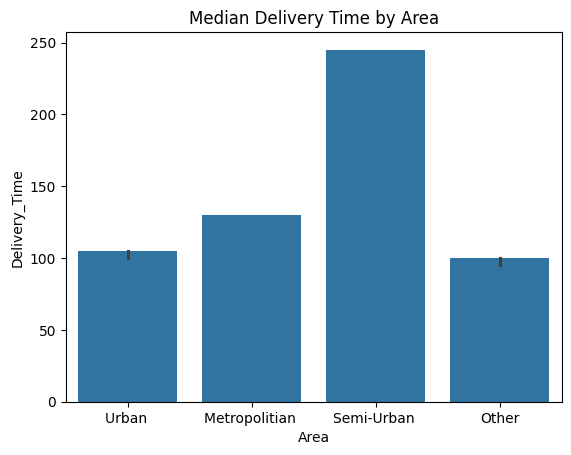

In [302]:
sns.barplot(data=df, x='Area', y='Delivery_Time', estimator='median')
plt.title("Median Delivery Time by Area")
plt.show()


Our analysis shows a clear difference in delivery across area types. Semi‑Urban areas experience the longest delivery times, with a median of 245 days, making them the slowest‑performing region in the dataset. In contrast, “Other” areas show the shortest delivery times, with a median of 100 days.

This suggests that Semi‑Urban regions may face structural or logistical challenges—such as road conditions, distance from distribution hubs, or limited courier availability.

Analyzing by Type of Weather

In [303]:
df.groupby('Weather')['Delivery_Time'].median().sort_values(ascending = False)

,Delivery_Time
Weather,
Cloudy,140.0
Fog,135.0
Sandstorms,125.0
Stormy,125.0
Windy,125.0
Sunny,100.0


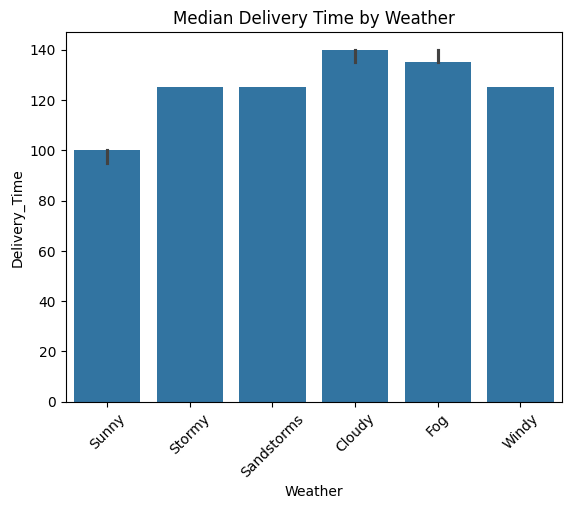

In [304]:
sns.barplot(data=df, x='Weather', y='Delivery_Time', estimator='median')
plt.title("Median Delivery Time by Weather")
plt.xticks(rotation=45)
plt.show()


We also seem to see a distinct difference in weather type vs delivery time as well.

Cloudy and Foggy conditions lead to the slowest deliveries, indicating that reduced visibility has a stronger operational impact than more dramatic weather events.

Interestingly, Stormy and Sandstorm conditions do not produce the highest delays, likely because extreme weather reduces the number of active deliveries or prompts companies to adjust routes and schedules.

As expected, Sunny conditions result in the quickest delivery times, reinforcing the idea that clear visibility and stable weather support more efficient operations.

Best/Worst performing Areas and Categories



In [305]:
#Analyzing Area
df.groupby('Area')[['Delivery_Time', 'Agent_Rating']].median().sort_values(by='Delivery_Time', ascending = False)

#Agent ratings are the lowest in semi-urabn areas, this can be expected as they have the highest delivery times meaning delivery times are affected by area and thus affect agent ratings.

,Delivery_Time,Agent_Rating
Area,,
Semi-Urban,245.0,4.6
Metropolitian,130.0,4.7
Urban,105.0,4.7
Other,100.0,4.7


In [306]:
#Analze by Category
df.groupby('Category')[['Delivery_Time', 'Agent_Rating']].median().sort_values(by='Delivery_Time', ascending=False)

#Category does not seem to show distinction in agent_ratings

,Delivery_Time,Agent_Rating
Category,,
Apparel,130.0,4.7
Cosmetics,130.0,4.7
Snacks,130.0,4.7
Sports,130.0,4.7
Skincare,130.0,4.7
Shoes,130.0,4.7
Pet Supplies,130.0,4.7
Kitchen,130.0,4.7
Clothing,125.0,4.7


Delivery Delays Vs Agent Ratings

/tmp/ipykernel_15710/608831636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Agent_Rating', palette='viridis')


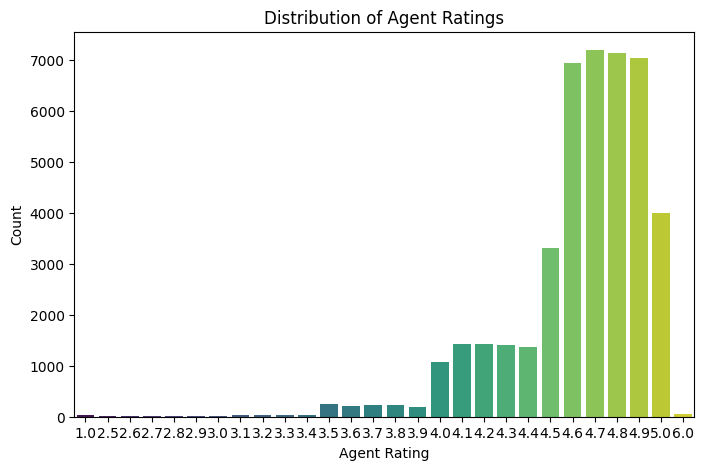

In [323]:
#Visualize our Agent Ratings
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Agent_Rating', palette='viridis')

plt.title("Distribution of Agent Ratings")
plt.xlabel("Agent Rating")
plt.ylabel("Count")
plt.show()

In [308]:
#Correlation between agent ratings and delivery time
df[['Delivery_Time', 'Agent_Rating']].corr()

#Our corelation coefficient of -0.289855 suggests delivery time does not seem to have too large of an effect on agent-rating


,Delivery_Time,Agent_Rating
Delivery_Time,1.000000,-0.289855
Agent_Rating,-0.289855,1.000000


However, at what point in delivery_time do we start to see agent ratings start to drop?

In [324]:
#split our dleivery-times into groups for better analysis
df['Delay_Group'] = pd.cut(df['Delivery_Time'], bins=[10, 30, 60, 120, 180, 270],labels=['10–30 days', '30–60 days', '60–120 days', '120–180 days', '180–270 days'])

In [325]:
df.groupby('Delay_Group')['Agent_Rating'].median()


/tmp/ipykernel_15710/2991460980.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Delay_Group')['Agent_Rating'].median()


,Agent_Rating
Delay_Group,
10–30 days,4.7
30–60 days,4.7
60–120 days,4.7
120–180 days,4.7
180–270 days,4.5


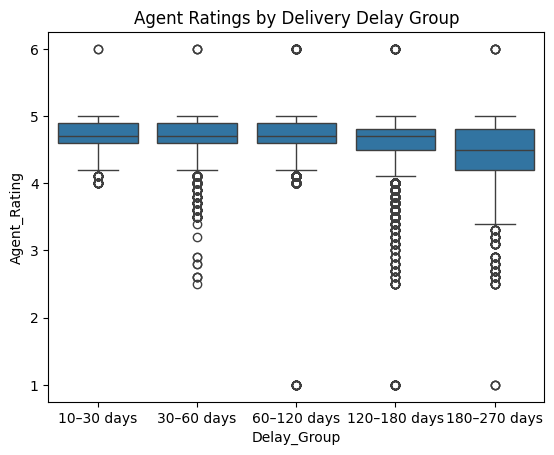

In [326]:
sns.boxplot(data=df, x='Delay_Group', y='Agent_Rating')
plt.title("Agent Ratings by Delivery Delay Group")
plt.show()



We begin to see agent ratings decline once delivery times exceed 180 days, and when we connect this with our area‑based analysis, a clear pattern emerges: Semi‑Urban areas consistently produce the highest delivery times, with a median around 245 days.

This strongly suggests that Semi‑Urban regions are the primary contributors to delayed deliveries and, in turn, lower agent ratings.

Meaning they should be prioritized for operational improvements if the goal is to raise both delivery speed and agent performance ratings.

# **MODEL TRAINING**
We will now move on to creating our model that will help us predict whether a delivery will be slow based on these features

In [312]:
#First lets make a threshold that qualifies what type of delivery_time will be considered slow.I will choose the top 20% delivery times to be considered slow
threshold = df['Delivery_Time'].quantile(0.80)
df['Slow_Delivery'] = (df['Delivery_Time'] >= threshold).astype(int)


Encoding Categorical Values

In [313]:
#creating encoded columns
df_model = pd.get_dummies(df[['Distance_in_km', 'Weather', 'Area', 'Category', 'Slow_Delivery']], drop_first=True)

Test/train Split

In [314]:
X = df_model.drop('Slow_Delivery', axis=1)
y = df_model['Slow_Delivery']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Create our model: Logistic Regression

In [315]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Evaluate our model

In [316]:
y_pred = model.predict(X_test)

#create a classification report
print(classification_report(y_test, y_pred))


#Create our confusion matrix
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      7001
           1       1.00      0.01      0.03      1747

    accuracy                           0.80      8748
   macro avg       0.90      0.51      0.46      8748
weighted avg       0.84      0.80      0.72      8748

[[7001    0]
 [1723   24]]


The model is very good at identifying non-slow deliveries and is highly accurate when it predicts a delivery will be slow.

However, it struggles with identifying actual slow deliveries, missing a large majority of them.

This means it's a good classifier for confirming a delivery is not slow, but very poor at flagging deliveries that will be slow.

This imbalance in performance is likely due to the class imbalance in our 'Slow_Delivery' target variable (where 'not slow' is the majority class).

Feature Importance

In [317]:
importance = pd.DataFrame({'feature': X.columns, 'coef': model.coef_[0]}).sort_values(by='coef', ascending=False)

#display top 20 feautures that have the most impact on the model's prediction
importance.head(20)


,feature,coef
7,Area_Semi-Urban,4.219031
20,Category_Skincare,0.084214
11,Category_Cosmetics,0.076205
1,Weather_Fog,0.045550
16,Category_Kitchen,0.035477
10,Category_Clothing,0.018778
22,Category_Sports,0.008414
9,Category_Books,0.005074
0,Distance_in_km,-0.000077
21,Category_Snacks,-0.003773


Trying a RandomeForest

In [318]:
#Create our randomforest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86      7001
           1       0.43      0.42      0.42      1747

    accuracy                           0.77      8748
   macro avg       0.64      0.64      0.64      8748
weighted avg       0.77      0.77      0.77      8748



Compared to your Logistic Regression model, the Random Forest model shows a trade-off:

Logistic Regression was very good at predicting non-slow deliveries (1.00 recall for '0') and had perfect precision for slow deliveries (1.00 precision for '1'), but it almost never predicted a delivery was slow (0.01 recall for '1'). It was too conservative.

Random Forest is more balanced. While its precision for 'slow' deliveries (0.43) is not perfect, it is much better at actually identifying slow deliveries (0.42 recall for '1') than the Logistic Regression model.

It makes more 'slow' predictions, and a reasonable portion of them are correct.

In [319]:
#What feautures matter the most according to our random forest?
importances = pd.DataFrame({'feature': X.columns,'importance': rf.feature_importances_}).sort_values(by='importance', ascending=False)

importances.head(20)


,feature,importance
0,Distance_in_km,0.818895
4,Weather_Sunny,0.030266
13,Category_Grocery,0.024048
1,Weather_Fog,0.021853
3,Weather_Stormy,0.017879
5,Weather_Windy,0.016883
2,Weather_Sandstorms,0.014502
8,Area_Urban,0.012222
7,Area_Semi-Urban,0.010353
6,Area_Other,0.003822


Testing with predictions

In [320]:
#Test with a prediction
def predict_delay(weather, area, category, distance):
    row = pd.DataFrame([{
        'Distance_in_km': distance,
        **{col: 1 if col == f"Weather_{weather}" else 0 for col in X.columns if col.startswith("Weather_")},
        **{col: 1 if col == f"Area_{area}" else 0 for col in X.columns if col.startswith("Area_")},
        **{col: 1 if col == f"Category_{category}" else 0 for col in X.columns if col.startswith("Category_")},
    }])
    return rf.predict(row)[0]


In [321]:
predict_delay("Fog", "Urban", "Kitchen", 12.5)

np.int64(0)

## Model Insights

The Random Forest model is a more practical choice if your goal is to identify slow deliveries, even if it means sacrificing some overall accuracy or having some false positives for 'slow' predictions.

It's better at identifying the minority class ('Slow_Delivery') compared to the Logistic Regression model, which was heavily biased towards predicting the majority class ('Not Slow').

The slightly lower overall accuracy is a result of this improved balance in predicting both classes.


# **CONCLUSION**

Overall, our analysis shows that delivery performance is shaped by a combination of geographic and environmental factors, and these patterns directly influence agent ratings.

Semi‑Urban areas consistently produce the longest delivery times, often exceeding 180 minutes, the point at which we begin to see agent ratings decline. This makes Semi‑Urban regions the most critical areas to target for operational improvements.

Weather conditions further reinforce this pattern. Cloudy and Foggy conditions lead to the slowest deliveries, suggesting that visibility challenges have a stronger impact on efficiency than more severe but less frequent conditions like storms or sandstorms.

Our machine‑learning model supports these findings by identifying Area, Weather, and Distance as key predictors of slow deliveries. The model successfully classifies high‑risk deliveries, allowing us to anticipate delays before they occur.

Together, these insights highlight where interventions, such as route optimization, resource allocation, or targeted training,  can have the greatest impact.

By focusing on Semi‑Urban regions and visibility‑related weather conditions, organizations can meaningfully improve both delivery times and agent ratings.